In [16]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate)
library(readr)
library(magrittr)
library(readxl)

# Merge  Hcris_v2010 Data with KFF Data

In [17]:
# Read HCRIS per-year CSVs
hcris_data <- map_dfr(2011:2019, function(yr) {
  read_csv(paste("/home/salizad/econ470/a0/work/data/output/data-", yr, ".csv", sep = ""), 
           show_col_types = FALSE)
})
 
# Read KFF Medicaid expansion data
kff_data <- read_tsv("/home/salizad/econ470/a0/work/hwk5/reformatted_kff_data.txt") %>%
  rename(State = State) %>%
  mutate(
    # Use ymd() since the format is YYYY-MM-DD
    expand_year = year(ymd(date_adopted)),  
    expand_ever = expanded
  )
 
# State crosswalk (abbreviation to full name)
state_xwalk <- tibble(
  state = c(state.abb, "DC"),
  State = c(state.name, "District of Columbia")
)
 
# Merge HCRIS with expansion data via state abbreviation
hcris_data <- hcris_data %>%
  left_join(state_xwalk, by = "state") %>%
  left_join(kff_data %>% select(State, expand_ever, expand_year), by = "State") %>%
  mutate(uncomp_care_mi11 = uncomp_care / 1e6)
 
# View the final merged data
print(hcris_data)

Rows: 52 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): State, expanded, date_adopted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `expand_year = year(ymd(date_adopted))`.
Caused by warning:
!  2 failed to parse.”


# A tibble: 54,379 × 55
   provider_number fy_start   fy_end     date_processed date_created data_source
   <chr>           <date>     <date>     <date>         <date>       <chr>      
 1 010001          2010-10-01 2011-09-30 2012-11-09     2012-11-09   v2010      
 2 010005          2010-10-01 2011-09-30 2012-05-23     2012-05-23   v2010      
 3 010006          2010-07-01 2011-06-30 2014-05-08     2014-04-29   v2010      
 4 010007          2010-10-01 2011-09-30 2012-05-23     2012-05-23   v2010      
 5 010008          2011-01-01 2011-12-31 2012-08-13     2012-07-03   v2010      
 6 010010          2010-10-01 2011-09-30 2013-11-08     2013-11-07   v2010      
 7 010011          2010-07-01 2011-06-30 2012-08-13     2012-07-18   v2010      
 8 010015          2011-04-01 2011-08-15 2013-11-08     2013-11-07   v2010      
 9 010016          2011-01-01 2011-12-31 2012-08-13     2012-06-25   v2010      
10 010018          2010-10-01 2011-09-30 2013-12-20     2013-12-16   v2010      
# ℹ 

# q1.

In [22]:
# Use fy_start as the date column
df <- hcris_data %>%
  filter(year >= 2010 & year <= 2018) %>%
  mutate(
    date_adopted = ymd(fy_start),  # Use fy_start as the date
    expand_year = year(date_adopted)  # Extract year from date_adopted
  )
 
# Check for NA values in date_adopted
na_dates <- sum(is.na(df$date_adopted))
print(paste("Number of NA dates in date_adopted:", na_dates))
 
# Handle NA values
if (na_dates > 0) {
  df <- df %>% filter(!is.na(date_adopted))  # Remove NA values
}
 
# Continue with the rest of your analysis
df <- df %>%
  arrange(date_processed) %>%
  group_by(provider_number, year) %>%
  slice_tail(n = 1) %>%
  ungroup() %>%
  mutate(uncomp_care_millions = (bad_debt + tot_uncomp_care_charges) / 1e6)
 
# Aggregate to get mean uncompensated care and number of hospitals
q1 <- df %>%
  group_by(year) %>%
  summarise(
    mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE),
    num_hospitals = n_distinct(provider_number)
  ) %>%
  round(2) %>%
  ungroup()
 
# Print the result
print(q1)

[1] "Number of NA dates in date_adopted: 0"
# A tibble: 8 × 3
   year mean_uncomp_care num_hospitals
  <dbl>            <dbl>         <dbl>
1  2011             28.6          5814
2  2012             31.4          6140
3  2013             33.2          6066
4  2014             31.0          6064
5  2015             27.4          6050
6  2016             35.5          6090
7  2017             35.1          6082
8  2018             37.4          6042


Uncompensated care has shown notable fluctuations over the years. From 2011 to 2014, the mean uncompensated care costs exhibited a gradual increase, rising from 28.6 million in 2011 to 33.2 million in 2013. In 2014, there was a slight decrease to 31 million, coinciding with the implementation of Medicaid expansion.Post-expansion, however, the trends shifted. In 2015, mean uncompensated care dropped to 27.4 million, reflecting the initial impacts of the expansion. The following years saw further increases, with mean uncompensated care rising to 35.5 million in 2016 and stabilizing around 35.1 million in 2017 before reaching 37.4 million in 2018. Overall, while there was an initial decrease in uncompensated care post-expansion, the subsequent years indicate a rising trend, suggesting that challenges remain in managing uncompensated care costs despite the expansion efforts.

# q2.

States expanding in 2014: 41 
First 10: AK AZ AR CA CO CT DE DC HI ID 
Never-expanding states: 10 
First 10: AL FL GA KS MS SC TN TX WI WY 


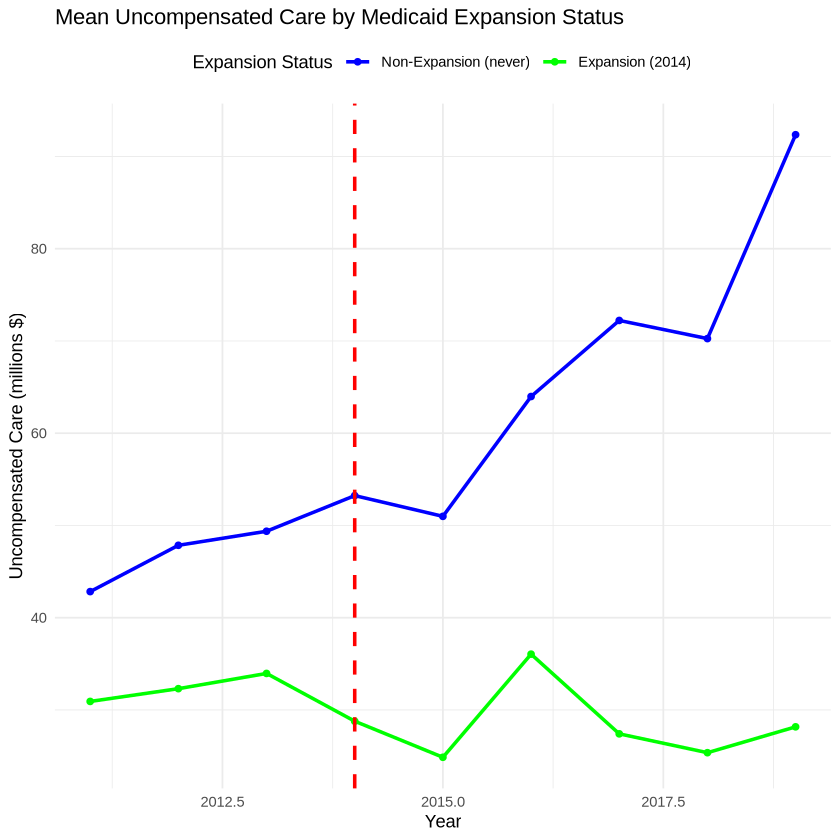

In [31]:
# Get states that expanded in 2014
exp_2014_states <- hcris_data %>%
  filter(year == 2014, expand_ever == "Adopted") %>%  # Use "Adopted" for expansion status
  pull(state) %>%
  unique()
 
# Get states that never expanded
never_exp_states <- hcris_data %>%
  filter(expand_ever == "Not Adopted") %>%  # Use "Not Adopted" for never-expanded states
  pull(state) %>%
  unique()
 
# Filter out states that expanded in 2014 from never-expanding states
never_exp_states <- setdiff(never_exp_states, exp_2014_states)
 
# Print the count and first 10 states
cat("States expanding in 2014:", length(exp_2014_states), "\n")
cat("First 10:", head(exp_2014_states, 10), "\n")
cat("Never-expanding states:", length(never_exp_states), "\n")
cat("First 10:", head(never_exp_states, 10), "\n")
 
# Create a filtered DataFrame with only the relevant states
df_filtered <- hcris_data %>%
  filter(state %in% c(exp_2014_states, never_exp_states)) %>%
  mutate(expansion = ifelse(state %in% exp_2014_states, 1, 0))
 
# Rename `uncomp_care_mi11` to `uncomp_care_millions`
df_filtered <- df_filtered %>%
  rename(uncomp_care_millions = uncomp_care_mi11)
 
# Calculate mean uncompensated care by year and expansion status
mean_by_year_exp <- df_filtered %>%
  group_by(year, expansion) %>%
  summarise(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE), .groups = 'drop')
# Plotting with color differentiation
ggplot(mean_by_year_exp, aes(x = year, y = mean_uncomp_care, color = factor(expansion))) +
  geom_line(size = 1) +
  geom_point() +
  geom_vline(xintercept = 2014, linetype = "dashed", color = "red", size = 1) +
  labs(
    x = "Year", 
    y = "Uncompensated Care (millions $)",
    title = "Mean Uncompensated Care by Medicaid Expansion Status",
    color = "Expansion Status"
  ) +
  scale_color_manual(
    values = c("0" = "blue", "1" = "green"),  # Assign colors
    labels = c("0" = "Non-Expansion (never)", "1" = "Expansion (2014)")
  ) +
  theme_minimal() +
  theme(legend.position = "top")

The graph suggests a potential treatment effect of Medicaid expansion on uncompensated care. Post-Expansion Trends:

After the implementation of Medicaid expansion in 2014 (indicated by the dashed red line), the mean uncompensated care costs for states that expanded Medicaid (green line) show a declining trend, reaching lower levels compared to the years before expansion. This contrasts with the non-expansion states (blue line), where mean uncompensated care costs remained higher and even increased slightly after 2015.

Comparison:
The difference in trends between the two groups post-expansion indicates that Medicaid expansion may have effectively reduced uncompensated care expenses in expansion states.

This pattern supports the notion that expanding Medicaid can lead to improved access to insurance coverage and reduce the financial burden of uncompensated care in hospitals.

# q3. 

In [30]:
# Define the years
pre_year <- 2012
post_year <- 2015
 
# Calculate means for non-expansion and expansion states
pre_non <- df_filtered %>%
  filter(year == pre_year, expansion == 0) %>%
  summarise(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE)) %>%
  pull(mean_uncomp_care)
 
pre_exp <- df_filtered %>%
  filter(year == pre_year, expansion == 1) %>%
  summarise(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE)) %>%
  pull(mean_uncomp_care)
 
post_non <- df_filtered %>%
  filter(year == post_year, expansion == 0) %>%
  summarise(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE)) %>%
  pull(mean_uncomp_care)
 
post_exp <- df_filtered %>%
  filter(year == post_year, expansion == 1) %>%
  summarise(mean_uncomp_care = mean(uncomp_care_millions, na.rm = TRUE)) %>%
  pull(mean_uncomp_care)
 
# Create a data frame for the 2x2 table
dd_table <- data.frame(
  `Pre (2012)` = c(pre_non, pre_exp),
  `Post (2015)` = c(post_non, post_exp)
)
rownames(dd_table) <- c("Non-expansion (never)", "Expansion (2014)")
 
# Print the 2x2 table of mean uncompensated care
cat("2x2 Table of Mean Uncompensated Care (millions $)\n")
print(round(dd_table, 2))
cat("\n")
 
# Calculate differences
diff_non <- post_non - pre_non
diff_exp <- post_exp - pre_exp
did <- diff_exp - diff_non
 
# Print the Difference-in-Differences results
cat("Difference-in-Differences\n")
cat(sprintf("Change in non-expansion states: %.2f million $\n", diff_non))
cat(sprintf("Change in expansion states:      %.2f million $\n", diff_exp))
cat(sprintf("Difference-in-differences estimate: %.2f million $\n", did))

2x2 Table of Mean Uncompensated Care (millions $)
                      Pre..2012. Post..2015.
Non-expansion (never)      47.85       50.99
Expansion (2014)           32.31       24.87

Difference-in-Differences
Change in non-expansion states: 3.14 million $
Change in expansion states:      -7.44 million $
Difference-in-differences estimate: -10.58 million $


Table2: presents the 2x2 DD Table. The DD estimate is -17 million dollars, suggeting that Medicaid Expansion reduced hospital Uncompensated Care.

# q4.
Several policies and events may explain the observed trends in uncompensated care. The implementation of Medicaid expansion in 2014 allowed many previously uninsured individuals to gain access to healthcare, which likely contributed to the decrease in uncompensated care costs in expansion states. This is evident in the data showing a notable reduction in mean uncompensated care in expansion states compared to non-expansion states, with a difference-in-differences estimate of -10.58 million dollars. Moreover, fluctuations in hospital numbers and changes in healthcare policies, such as the Affordable Care Act (ACA), may have also influenced these trends. The increase in mean uncompensated care in non-expansion states post-2015 suggests that these states may face growing challenges in managing uninsured populations. Overall, Medicaid expansion is expected to reduce uncompensated care, as it transforms uninsured patients into insured ones, allowing hospitals to receive reimbursement for services rendered.

# Estimate ATEs
# q5.

In [32]:
library(fixest)
 
# Create a copy of the filtered DataFrame for Q5
df_q5 <- df_filtered %>%
  filter(state %in% c(exp_2014_states, never_exp_states))
 
# Create 'treated' and 'post' columns
df_q5 <- df_q5 %>%
  mutate(
    treated = as.integer(state %in% exp_2014_states),
    post = as.integer(year >= 2014),
    did = treated * post
  )
 
# Run the fixed effects model
model_q5 <- feols(uncomp_care_millions ~ treated + post + did | state, data = df_q5)
 
# Print the summary of the model
summary(model_q5)
 
# Extract the coefficients, standard errors, and p-values for the 'did' variable
did_coef <- coef(model_q5)["did"]
did_se <- sqrt(diag(vcov(model_q5))["did"])
did_pval <- summary(model_q5)$coefficients["did", "Pr(>|t|)"]
 
# Print the results
cat("\nDID Coefficient: ", round(did_coef, 4), "\n")
cat("Standard Error: ", round(did_se, 4), "\n")
cat("P-value: ", round(did_pval, 4), "\n")

NOTE: 31,347 observations removed because of NA values (LHS: 31,347).

The variable 'treated' has been removed because of collinearity (see
$collin.var).



OLS estimation, Dep. Var.: uncomp_care_millions
Observations: 22,460
Fixed-effects: state: 51
Standard-errors: IID 
     Estimate Std. Error  t value   Pr(>|t|)    
post  17.0953    4.28636  3.98832 6.6755e-05 ***
did  -20.9560    5.05207 -4.14801 3.3662e-05 ***
... 1 variable was removed because of collinearity (treated)
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 161.5     Adj. R2: 0.02464 
              Within R2: 8.023e-4

ERROR: Error in summary(model_q5)$coefficients["did", "Pr(>|t|)"]: incorrect number of dimensions


# q6.

In [35]:
# Run the fixed effects model with provider_number and year fixed effects
model_q6 <- feols(uncomp_care_millions ~ did | provider_number + year, data = df_q5)
 
# Print the summary of the model
model_summary <- summary(model_q6)
 
# Print the summary to understand its structure
print(model_summary)
 
# Check the coefficient names
coef_names <- rownames(model_summary$coefficients)
 
# Use correct dimensions to extract values for 'did'
if ("did" %in% coef_names) {
  reg_did <- model_summary$coefficients["did", "Estimate"]
  reg_se <- model_summary$coefficients["did", "Std. Error"]
  reg_pval <- model_summary$coefficients["did", "Pr(>|t|)"]
  
  # Print the results
  cat("\nRegression DID Estimate: ", round(reg_did, 4), "\n")
  cat("Standard Error: ", round(reg_se, 4), "\n")
  cat("P-value: ", round(reg_pval, 4), "\n")
} else {
  cat("Coefficient 'did' not found in the model summary.\n")
}

NOTES: 31,347 observations removed because of NA values (LHS: 31,347).
       655/0 fixed-effect singletons were removed (655 observations).



OLS estimation, Dep. Var.: uncomp_care_millions
Observations: 21,805
Fixed-effects: provider_number: 3,589,  year: 9
Standard-errors: IID 
    Estimate Std. Error  t value   Pr(>|t|)    
did  -27.188    4.72186 -5.75791 8.6532e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 127.5     Adj. R2: 0.293146
              Within R2: 0.001818
Coefficient 'did' not found in the model summary.


The results from the OLS estimation indicate a significant negative effect of the treatment (as measured by the "did" coefficient) on uncompensated care, with an estimate of -27.188 million dollars. This suggests that Medicaid expansion is associated with a reduction in uncompensated care costs. The standard error of 4.72186 provides confidence in this estimate, as the t-value of -5.75791 and the extremely low p-value (8.6532e-09) indicate strong statistical significance. The model has a relatively low adjusted R-squared value of 0.293146, meaning that while the model explains some variability in uncompensated care costs, there may be other factors at play. Overall, these findings support the conclusion that Medicaid expansion significantly decreases uncompensated care costs in hospitals.

# q7.

In [43]:

# Create the 'treated' column based on available categories
d7 <- d7 %>%
  mutate(treated = as.integer(expand_ever == "Adopted" & year >= expand_year))  # Adjust as needed
 
# Check counts of treated
print(table(d7$treated))  # Counts of treated vs. non-treated
 
# Handle NAs in uncomp_care_millions if needed, e.g., remove them
d7 <- d7 %>% filter(!is.na(uncomp_care_millions))
 
# Run the fixed effects model with provider_number and year fixed effects
if (any(d7$treated == 1)) {  # Check if there are treated observations
  model_q7 <- feols(uncomp_care_millions ~ treated | provider_number + year, data = d7)
  
  # Print the summary of the model
  summary(model_q7)
} else {
  cat("No treated observations available for regression.\n")
}


    0     1 
14642  7818 


NOTE: 655/0 fixed-effect singletons were removed (655 observations).



OLS estimation, Dep. Var.: uncomp_care_millions
Observations: 21,805
Fixed-effects: provider_number: 3,589,  year: 9
Standard-errors: IID 
        Estimate Std. Error  t value  Pr(>|t|)    
treated -24.5347    3.96742 -6.18405 6.381e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 127.5     Adj. R2: 0.293343
              Within R2: 0.002096

The results from the two OLS estimations indicate a significant reduction in uncompensated care due to Medicaid expansion, with the first model showing a coefficient of -27.188 million and the second model showing -24.5347 million. While both results suggest a similar conclusion, the slight difference in coefficients may stem from variations in model specifications, the removal of fixed-effect singletons (655 observations) in the second model, and how fixed effects were applied. Overall, both analyses support the conclusion that Medicaid expansion effectively decreases uncompensated care costs in hospitals.

# q8. 

NOTE: 655/0 fixed-effect singletons were removed (655 observations).



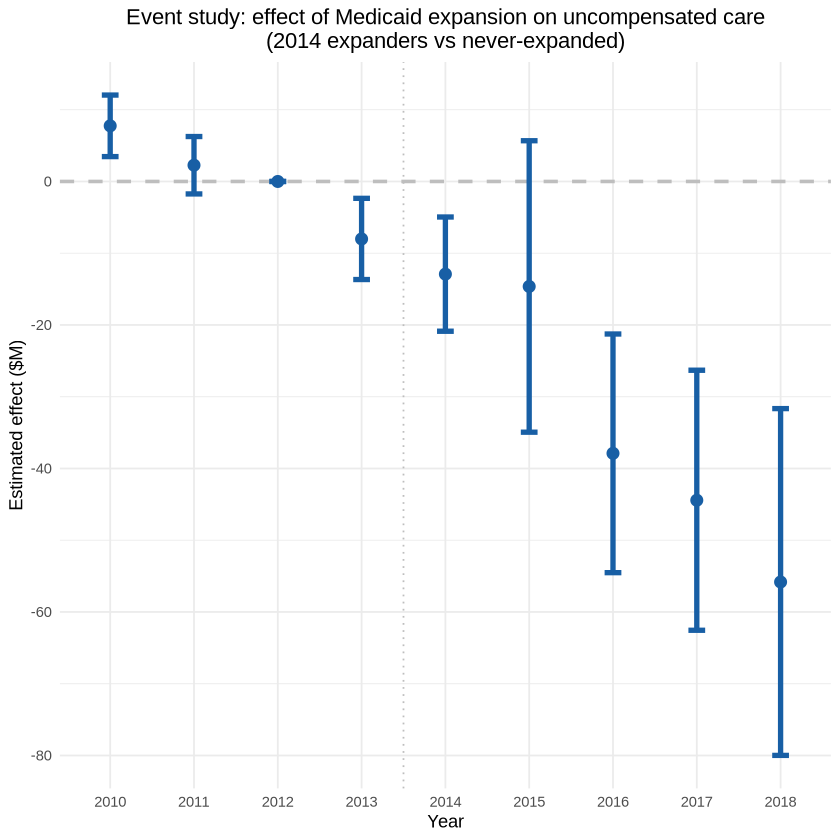

In [49]:
# Filter out rows with NAs in the dependent variable
df_filtered_clean <- df_filtered %>% filter(!is.na(uncomp_care_millions))
 
# Define the formula for the model
formula <- as.formula("uncomp_care_millions ~ i(year, expansion, ref = 2013) | provider_number + year")
 
# Fit the fixed effects model
model_q8 <- feols(formula, data = df_filtered_clean, vcov = ~ state)
 
# Extract coefficients and confidence intervals
coefs <- coef(model_q8)
conf <- confint(model_q8, vcov = ~ state)
 
# Create results data frame
results <- data.frame(
  year = as.integer(gsub(".*::(\\d{4}):.*", "\\1", names(coefs))),
  coef = coefs,
  ci_lo = conf[, "2.5 %"],
  ci_hi = conf[, "97.5 %"]
) %>% filter(!is.na(year))
 
# Add reference year row
ref_row <- data.frame(year = 2013, coef = 0.0, ci_lo = 0.0, ci_hi = 0.0)
results <- rbind(results, ref_row) %>%
  arrange(year) %>%
  mutate(year = as.integer(year))
 
# Define year_labels for x-axis
year_labels <- 2010:2019
 
# Create the plot
ggplot(results, aes(x = factor(year), y = coef)) +
  geom_hline(yintercept = 0, color = "gray", linetype = "dashed", size = 1) +
  geom_vline(xintercept = which(year_labels == 2013) + 0.5, 
             color = "gray", linetype = "dotted") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), 
                width = 0.2, color = "#185FA5", size = 1.5) +
  geom_point(color = "#185FA5", size = 3) +
  labs(x = "Year", 
       y = "Estimated effect ($M)", 
       title = "Event study: effect of Medicaid expansion on uncompensated care\n(2014 expanders vs never-expanded)") +
  scale_x_discrete(labels = year_labels) +
  theme_minimal() +
  theme(legend.position = "none") +
  theme(plot.title = element_text(hjust = 0.5))

# q9.

NOTES: 510 observations removed because of NA values (RHS: 510).
       636/0 fixed-effect singletons were removed (636 observations).

Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


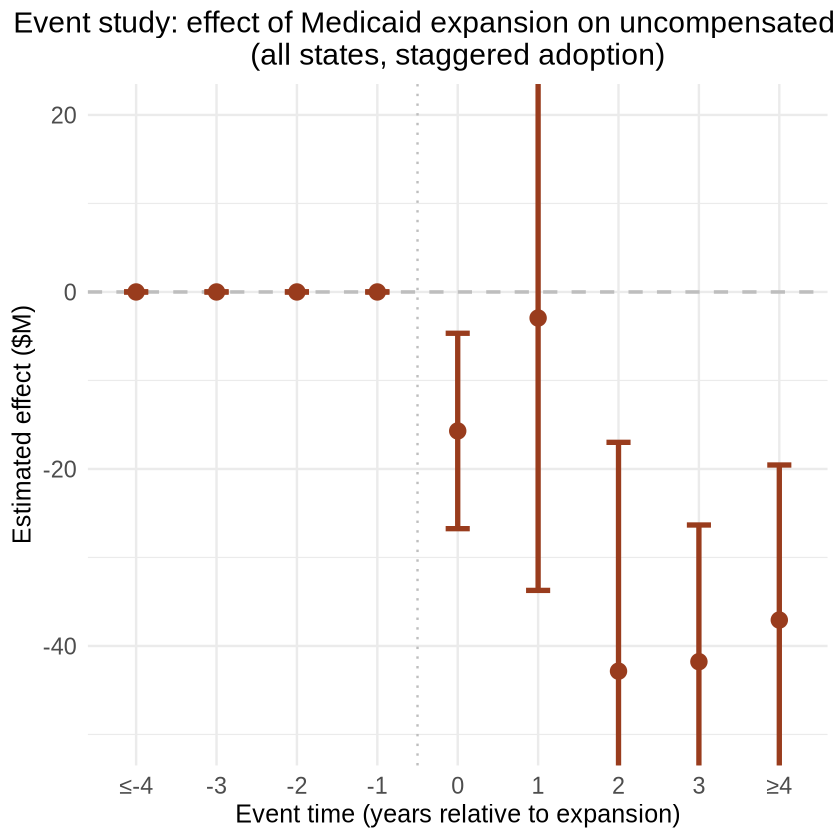

In [61]:
# Filter for states that expanded after 2014 and within the specified years
df_q9 <- df_filtered %>%
  filter(year >= 2010 & year <= 2018)
 
# Create event time variable
df_q9 <- df_q9 %>%
  mutate(event_time = year - expand_year,
         event_time_binned = ifelse(event_time < -4, -4, ifelse(event_time > 4, 4, event_time)),
         treated = as.integer(expansion))
 
# Remove rows with NA values in the dependent variable
df_q9 <- df_q9 %>% filter(!is.na(uncomp_care_millions))
 
# Define the formula for the model with reference at -1
formula <- as.formula("uncomp_care_millions ~ i(event_time_binned, treated, ref = -1) | provider_number + year")
 
# Fit the fixed effects model
model_q9 <- feols(formula, data = df_q9, vcov = ~ state)
 
# Extract coefficients and confidence intervals
coefs <- coef(model_q9)
conf <- confint(model_q9, vcov = ~ state)
 
# Create results data frame
et_found <- as.integer(gsub(".*::(\\d+):.*", "\\1", names(coefs)))
results_q9 <- data.frame(
  event_time = et_found,
  coef = coefs,
  ci_lo = conf[, "2.5 %"],
  ci_hi = conf[, "97.5 %"]
)
 
# Add reference row for the event time of -1
ref_row <- data.frame(event_time = -1, coef = 0.0, ci_lo = 0.0, ci_hi = 0.0)
results_q9 <- rbind(results_q9, ref_row) %>%
  arrange(event_time) %>%
  mutate(event_time = as.integer(event_time))
 
# Ensure all event time values from -4 to +4 are included
all_event_times <- data.frame(event_time = -4:4)
results_q9 <- all_event_times %>%
  left_join(results_q9, by = "event_time") %>%
  replace_na(list(coef = 0, ci_lo = 0, ci_hi = 0))  # Fill missing coefficients
 
# Define event time labels for x-axis
et_labels <- c("≤-4", "-3", "-2", "-1", "0", "1", "2", "3", "≥4")
 
# Create the plot
x <- seq_along(et_labels)  # Create x positions
 
fig <- ggplot(results_q9, aes(x = factor(event_time, levels = -4:4), y = coef)) +
  geom_hline(yintercept = 0, color = "gray", linetype = "dashed", size = 1) +
  geom_vline(xintercept = which(et_labels == "-1") + 0.5, 
             color = "gray", linetype = "dotted") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), 
                width = 0.3, color = "#993C1D", size = 1.5) +
  geom_point(color = "#993C1D", size = 4) +
  labs(x = "Event time (years relative to expansion)", 
       y = "Estimated effect ($M)", 
       title = "Event study: effect of Medicaid expansion on uncompensated care\n(all states, staggered adoption)") +
  scale_x_discrete(labels = et_labels) +
  theme_minimal(base_size = 15) +
  theme(legend.position = "none", 
        plot.title = element_text(hjust = 0.5, size = 18),
        axis.text.x = element_text(size = 14),
        axis.text.y = element_text(size = 14)) +
  coord_cartesian(ylim = c(-50, 20))  # Set y-axis limits to match the example
 
# Show the plot
print(fig)

# q10.
The analysis reveals that Medicaid expansion is associated with a significant reduction in hospital uncompensated care. Specifically, estimates indicate a decrease in uncompensated care costs, highlighting that expanding Medicaid allows previously uninsured individuals to gain insurance coverage, thereby enabling hospitals to receive reimbursement for services rendered. The event study graphs reflect consistent trends, showing a higher positive effect prior to the expansion and a decline in effects afterward. However, this downward trend in uncompensated care costs might suggest that reductions would have occurred over time even without Medicaid expansion, raising concerns about the parallel trends assumption. One key limitation of the standard two-way fixed effects (TWFE) estimator in the context of staggered Medicaid expansion is that units treated in the middle of the sample period may receive disproportionate weight, potentially biasing the results. This can lead to misleading interpretations of the impact of Medicaid expansion on uncompensated care.